In [2]:
!pip install folium

In [3]:
!pip install contextily

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/ML/Tugas/Tugas11/data/earthquake_dataset.csv')
df.head()

,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16944 entries, 0 to 16943
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  16944 non-null  object 
 1   Time (UTC)            16944 non-null  object 
 2   City                  16944 non-null  object 
 3   Country               16944 non-null  object 
 4   Latitude              16944 non-null  float64
 5   Longitude             16944 non-null  float64
 6   Earthquake Magnitude  16944 non-null  float64
 7   Depth (km)            16944 non-null  float64
 8   Impact Score          16944 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 1.2+ MB


In [7]:
df.isnull().sum()

,0
Date,0
Time (UTC),0
City,0
Country,0
Latitude,0
Longitude,0
Earthquake Magnitude,0
Depth (km),0
Impact Score,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
#Buat peta dasar Indonesia
peta = folium.Map(location=[0, 0], zoom_start=2)

# Buat list data [lat, long, value) untuk heatmap
data_heatmap = df[['Latitude', 'Longitude', 'Impact Score']].values.tolist()

#Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=17, blur=15, max_zoom=8).add_to(peta)

#Tampilkan peta
peta

In [ ]:
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

#Jitter koordinat agar tidak tumpang tindih
np.random.seed(42)
long_peta = df['Longitude'] + np.random.uniform (-0.05, 0.05, size=len (df))
lat_peta = df['Latitude'] + np.random.uniform(-0.05, 0.05, size=len(df))
# Konversi ke GeoDataFrame
gdf = gpd.GeoDataFrame (
    df,
    geometry=gpd.points_from_xy(long_peta, lat_peta),
    crs='EPSG:4326'
)
#Proyeksi ke Web Mercator
gdf = gdf.to_crs(epsg=3857)

ImpactScore = df.groupby("Country") ["Impact Score"].mean()
top_5 = ImpactScore.sort_values (ascending=False).head(5)
bottom_5 = ImpactScore.sort_values().head(5)

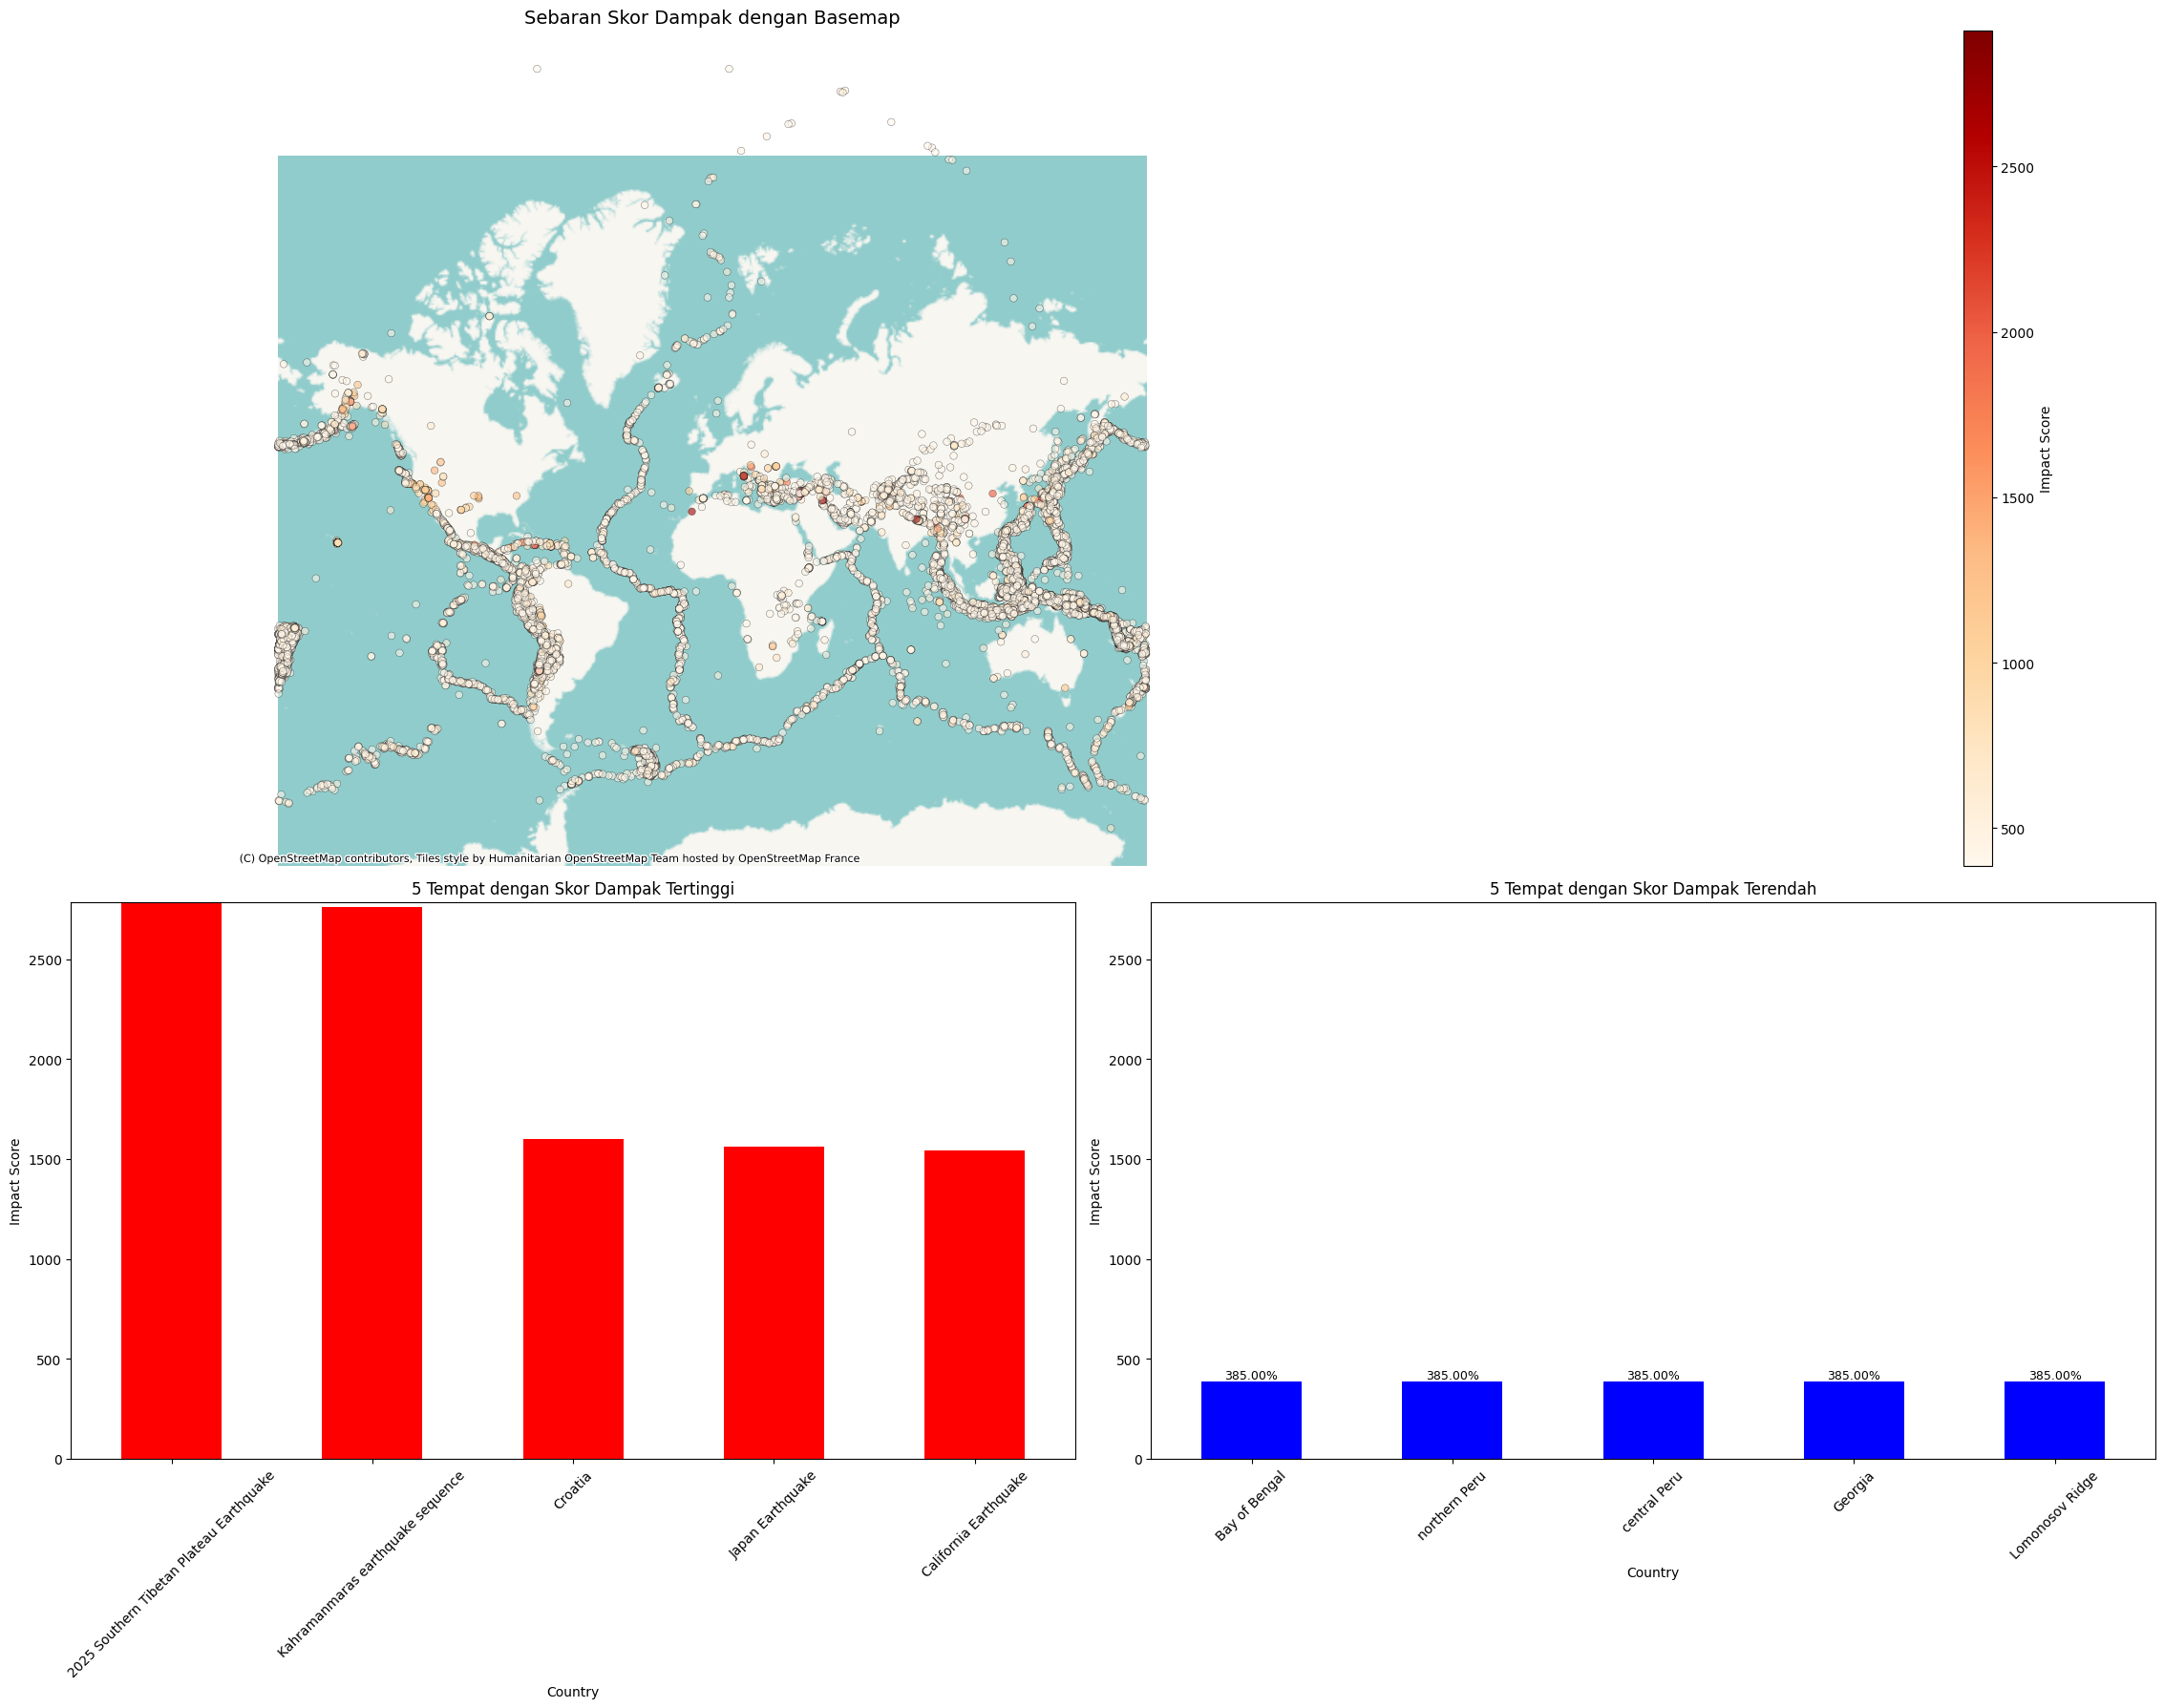

In [ ]:
#Buat layout dengan GridSpec
fig = plt.figure(figsize=(23,18))
gs = gridspec.GridSpec(2, 2, height_ratios=[3,2])

# Row 1: Peta sebaran (colspan=2)
ax_map = plt.subplot(gs[0,:])
divider = make_axes_locatable(ax_map)
cax = divider.append_axes("right", size="3%", pad=8.1)

gdf.plot(
    ax=ax_map,
    column="Impact Score",
    cmap="OrRd",
    legend=True,
    legend_kwds={'label': "Impact Score", 'orientation': "vertical"},
    cax=cax,
    markersize=30,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6
)

ctx.add_basemap(ax_map)
ax_map.set_title("Sebaran Skor Dampak dengan Basemap", fontsize=14)
ax_map.axis('off')

# --Row 2: Bar chart top & bottom (stacked vertically di satu kolom) ---
ax_top = plt.subplot(gs[1, 0])
bars_top = top_5.plot(kind='bar', ax=ax_top, color='red')
ax_top.set_title("5 Tempat dengan Skor Dampak Tertinggi")
ax_top.set_ylabel("Impact Score")
ax_top.set_xlabel("Country")
ax_top.tick_params(axis='x', rotation=45)

ax_bottom = plt.subplot(gs[1, 1])
bars_bottom = bottom_5.plot(kind='bar', ax=ax_bottom, color='blue')
ax_bottom.set_title("5 Tempat dengan Skor Dampak Terendah")
ax_bottom.set_ylabel("Impact Score")
ax_bottom.set_xlabel("Country")
ax_bottom.tick_params(axis='x', rotation=45)

#Tambahkan anotasi
for i, val in enumerate(bottom_5):
    ax_bottom.text(i, val+ 0.2, f"{val:.2f}%", ha='center', va='bottom', fontsize=9)

#Sinkronisasi skala Y kedua chart
max_val = max(top_5.max(), bottom_5.max())
ax_top.set_ylim(0, max_val + 1)
ax_bottom.set_ylim(0, max_val + 1)
#Sinkronisasi skala Y kedua chart
max_val = max(top_5.max(), bottom_5.max())
ax_top.set_ylim(0, max_val + 1)
ax_bottom.set_ylim(0, max_val + 1)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Date', 'Time (UTC)', 'City', 'Country', 'Latitude', 'Longitude',
       'Earthquake Magnitude', 'Depth (km)', 'Impact Score'],
      dtype='object')

In [ ]:
from scipy.stats import shapiro

normality_test = df.drop(columns=['Date', 'Time (UTC)', 'City', 'Country'])
normality_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16944 entries, 0 to 16943
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Latitude              16944 non-null  float64
 1   Longitude             16944 non-null  float64
 2   Earthquake Magnitude  16944 non-null  float64
 3   Depth (km)            16944 non-null  float64
 4   Impact Score          16944 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 662.0 KB


In [ ]:
stat, p = shapiro(normality_test)
print("Statistik: ", stat)
print("P-value: ", p)

if p > 0.05:
  print("Data berdistribusi normal (tidak tolak H0)")
else:
  print("Data tidak berdistribusi normal (tolak H0)")

Statistik:  0.7722328495296032
P-value:  5.860574096165684e-132
Data tidak berdistribusi normal (tolak H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 84720.
  res = hypotest_fun_out(*samples, **kwds)


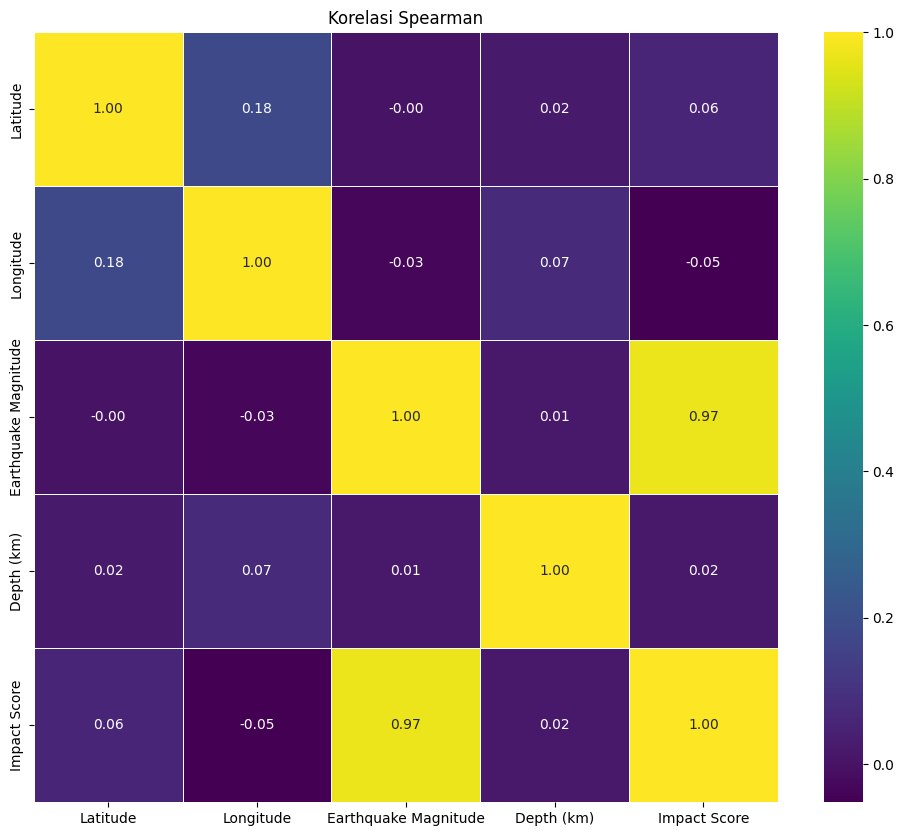

In [ ]:
cor = normality_test

corr_matrix = cor.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Spearman')
plt.show()

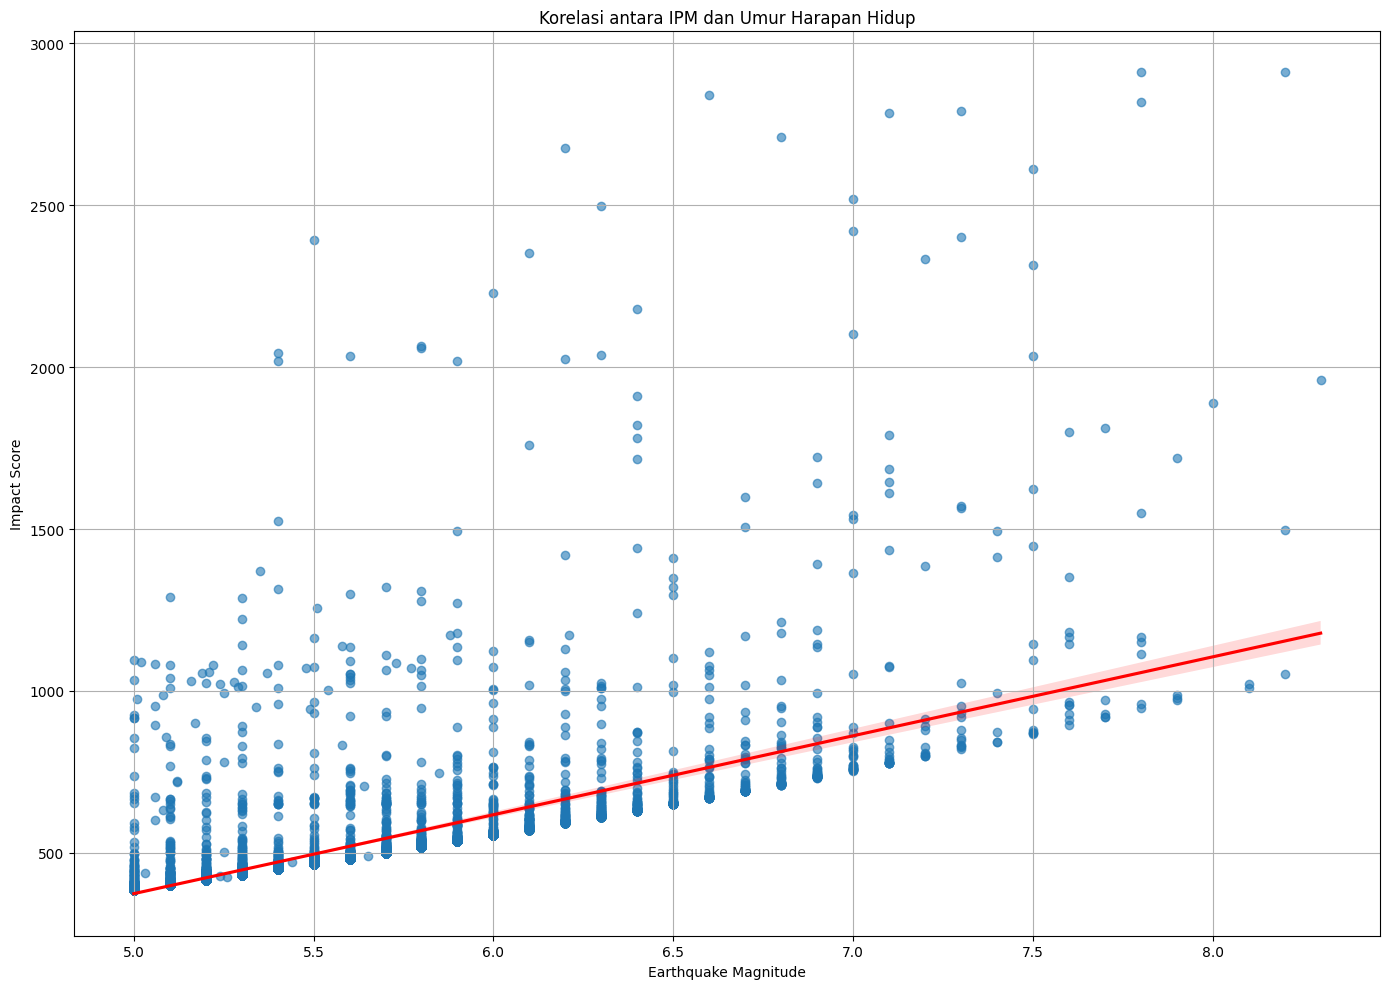

In [ ]:
plt.figure(figsize=(14, 10))
sns.regplot(
    x="Earthquake Magnitude",
    y="Impact Score",
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)
plt.title("Korelasi antara IPM dan Umur Harapan Hidup")
plt.xlabel("Earthquake Magnitude")
plt.ylabel("Impact Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Normalisasi**

In [12]:
normal_df = df.drop(columns=['Date', 'Time (UTC)', 'City', 'Country'])
normal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16944 entries, 0 to 16943
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Latitude              16944 non-null  float64
 1   Longitude             16944 non-null  float64
 2   Earthquake Magnitude  16944 non-null  float64
 3   Depth (km)            16944 non-null  float64
 4   Impact Score          16944 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 662.0 KB


In [13]:
from sklearn.preprocessing import RobustScaler

column_names = normal_df.columns
scaler = RobustScaler()
normalisasi_df = scaler.fit_transform(normal_df)
normalisasi_df = pd.DataFrame (normal_df, columns=column_names)
normalisasi_df.head()

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,-6.1233,147.5932,5.1,59.033,400
1,17.2871,-97.4400,5.6,63.551,503
2,-55.7385,-27.1122,6.0,35.379,554
3,41.9788,15.4490,5.0,8.742,389
4,1.1364,120.2317,5.4,26.072,449


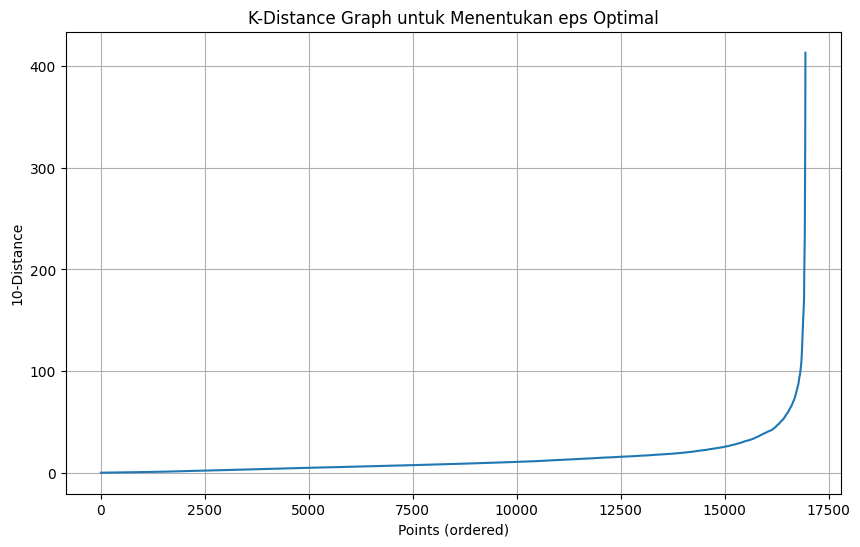

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

#Gunakan data hasil normalisasi
X = normal_df.values

# Tentukan jumlah tetangga (min_samples biasanya 4-10)
k = 10

# Fit nearest neighbors
neighbors = NearestNeighbors (n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors (X)

#Ambil jarak tetangga ke-k (k-distance)
k_distances = np.sort(distances [:, k-1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph untuk Menentukan eps Optimal")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

In [29]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN (eps=40, min_samples=10)
labels = dbscan.fit_predict(normalisasi_df.values)
df["Cluster_DBSCAN"] = labels
print(df["Cluster_DBSCAN"].value_counts())

Cluster_DBSCAN
 0    15887
-1      587
 1      286
 2       78
 4       37
 3       34
 6       13
 7       11
 5       11
Name: count, dtype: int64


In [30]:
from sklearn.metrics import silhouette_score

mask = labels != - 1 #hilangkan noise
score = silhouette_score (normal_df [mask], labels [mask])
print("Silhouette Score:", score)

Silhouette Score: 0.29447386721040125


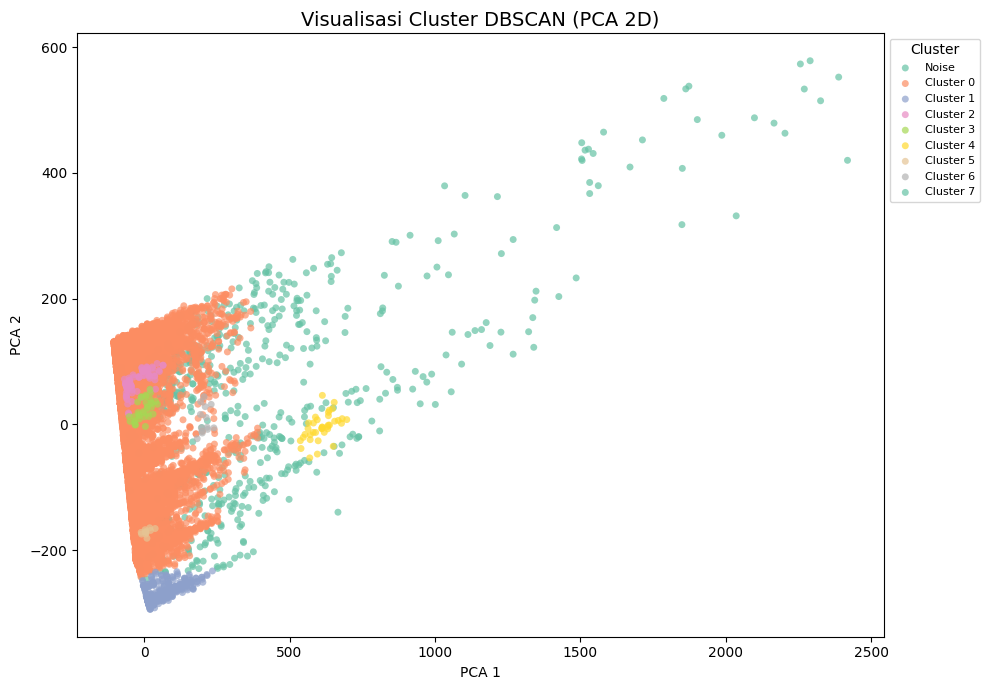

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# PCA 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(normal_df)

# Plot
plt.figure(figsize=(10, 7))

# Noise dan cluster dipisah supaya rapi
unique_labels = np.unique(labels)

# Warna random untuk cluster
palette = sns.color_palette("Set2", len(unique_labels))

for cluster_id, color in zip(unique_labels, palette):
    mask = labels == cluster_id
    label_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"

    plt.scatter(
        reduced[mask, 0], reduced[mask, 1],
        s=25,
        c=[color],
        label=label_name,
        alpha=0.7,
        edgecolors='none'
    )

plt.title("Visualisasi Cluster DBSCAN (PCA 2D)", fontsize=14)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(loc='upper left', bbox_to_anchor=(1,1), title="Cluster", fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
def klasifikasi_db(x):
    if x == 0:
      return "Baik"
    elif x == -1:
      return "Noise"
    else:
      return "Kurang"

df['Klasifikasi_DBSCAN'] = df ['Cluster_DBSCAN'].apply(klasifikasi_db)

print(df['Klasifikasi_DBSCAN'].value_counts())

Klasifikasi_DBSCAN
Baik      15887
Noise       587
Kurang      470
Name: count, dtype: int64


In [33]:
cluster_summary_db = df.drop(columns=['Date', 'Time (UTC)', 'City', 'Country']
                             ).groupby('Klasifikasi_DBSCAN').mean()
cluster_summary_db

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score,Cluster_DBSCAN
Klasifikasi_DBSCAN,,,,,,
Baik,-3.362486,35.930023,5.295968,34.962594,438.409077,0.000000
Kurang,-13.583085,-79.904410,5.390766,471.259969,504.614894,1.919149
Noise,9.308194,10.616115,6.302998,212.123168,870.548552,-1.000000


In [34]:
# Data untuk hover
import plotly.express as px
df_pca_db = pd. DataFrame (reduced, columns=["PCA 1", "PCA 2"])
df_pca_db["Klasifikasi_DBSCAN"] = df["Klasifikasi_DBSCAN"].values
df_pca_db["Country"] = df ["Country"].values
# Plotly interaktif
fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",
    hover_name="Country",
    title="Persebaran Data Berdasarkan Klasifikasi (DBSCAN)",
    width = 1500,
    height=900
)

fig.show()